# Lista de Exercícios: Programação Linear (Interpretação Geométrica)
## Aluno: Eduardo C. Ceretta

---


### Exercício 1: Otimização de Infraestrutura em Nuvem (IaaS)

**Contexto:** Uma startup de inteligência artificial precisa alocar instâncias de computação na nuvem para processar um novo pipeline de dados. Ela pode escolher entre dois tipos de instâncias: **Instâncias Standard ($x_1$)** e **Instâncias High-Performance ($x_2$)**.

Cada instância do tipo Standard custa \$20$ por hora e possui 4 vCPUs e 8 GB de RAM. Cada instância High-Performance custa \$50$ por hora e possui 8 vCPUs e 32 GB de RAM. O pipeline exige, no mínimo, 40 vCPUs e 96 GB de RAM para rodar sem gargalos. Por limitações de cota do provedor, a startup não pode contratar mais do que 12 instâncias no total.

**Formule o problema de PL para minimizar o custo horário e resolva geometricamente:**

1. Identifique a função objetivo e as restrições (técnicas e de não-negatividade).
2. Desenhe a região viável no plano cartesiano.
3. Determine a combinação ideal de instâncias ($x_1, x_2$) e o custo mínimo.

**--- RESPOSTA ---**

* **Variáveis:** `x1` (Standard), `x2` (High-Performance)
* **Objetivo:** Minimizar `Z = 20x1 + 50x2`
* **Restrições:**
  * `4x1 + 8x2 >= 40` (vCPUs)
  * `8x1 + 32x2 >= 96` (RAM)
  * `x1 + x2 <= 12` (Limite de instâncias)
  * `x1, x2 >= 0`
* **Vértices Viáveis:** (0, 12), (0, 5), (12, 0), (8, 1)
* **Solução Ótima:** `x1 = 8`, `x2 = 1`. Custo Mínimo = $210.


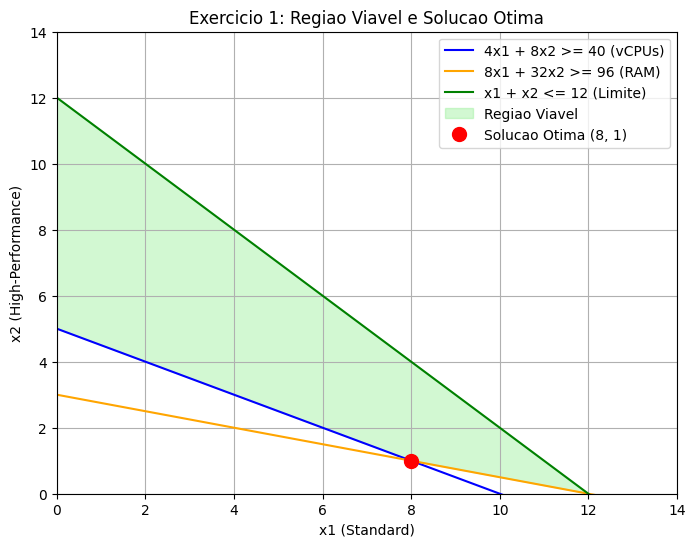

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(0, 16, 400)
y1 = (40 - 4*x1) / 8
y2 = (96 - 8*x1) / 32
y3 = 12 - x1

plt.figure(figsize=(8, 6))
plt.plot(x1, y1, label='4x1 + 8x2 >= 40 (vCPUs)', color='blue')
plt.plot(x1, y2, label='8x1 + 32x2 >= 96 (RAM)', color='orange')
plt.plot(x1, y3, label='x1 + x2 <= 12 (Limite)', color='green')

plt.fill([0, 8, 12, 0], [5, 1, 0, 12], color='lightgreen', alpha=0.4, label='Regiao Viavel')
plt.plot(8, 1, 'ro', markersize=10, label='Solucao Otima (8, 1)')

plt.xlim(0, 14)
plt.ylim(0, 14)
plt.xlabel('x1 (Standard)')
plt.ylabel('x2 (High-Performance)')
plt.title('Exercicio 1: Regiao Viavel e Solucao Otima')
plt.legend()
plt.grid(True)
plt.show()

---
### Exercício 2: Alocação de Banda e Roteamento de Tráfego

**Contexto:** Um roteador de borda de um provedor de internet precisa gerenciar o tráfego de dois serviços de streaming: **Stream Básico ($x_1$)** e **Stream Premium ($x_2$)** (valores medidos em milhares de conexões simultâneas). O provedor recebe um benefício de qualidade de serviço (QoS) avaliado em 3 pontos por unidade de Stream Básico e 5 pontos por unidade de Stream Premium.

O processamento desse tráfego consome a capacidade de dois switches de núcleo (A e B). Cada switch possui um limite máximo de pacotes por segundo que consegue processar:
* **Switch A:** Cada unidade de Stream Básico consome 2 Gbps de largura de banda e o Premium consome 4 Gbps. A capacidade máxima do Switch A é de 24 Gbps.
* **Switch B:** Cada unidade de Stream Básico consome 3 Gbps e o Premium consome 2 Gbps. A capacidade máxima do Switch B é de 22 Gbps.

**Formule o problem de PL para maximizar a pontuação de QoS e resolva geometricamente:**

1. Monte o sistema de inequações e a função objetivo.
2. Esboce o polígono que representa a região viável.
3. Encontre o ponto extremo (vértice) que maximiza o QoS.

**--- RESPOSTA ---**

* **Variáveis:** `x1` (Básico), `x2` (Premium)
* **Objetivo:** Maximizar `Z = 3x1 + 5x2`
* **Restrições:**
  * `2x1 + 4x2 <= 24` (Switch A)
  * `3x1 + 2x2 <= 22` (Switch B)
  * `x1, x2 >= 0`
* **Interseção das Restrições:** `2x1 + 4x2 = 24` e `3x1 + 2x2 = 22` -> Ponto (5, 3.5)
* **Vértices Viáveis:** (0, 0), (0, 6), (7.33, 0), (5, 3.5)
* **Solução Ótima:** `x1 = 5`, `x2 = 3.5`. QoS Máximo = 32.5.


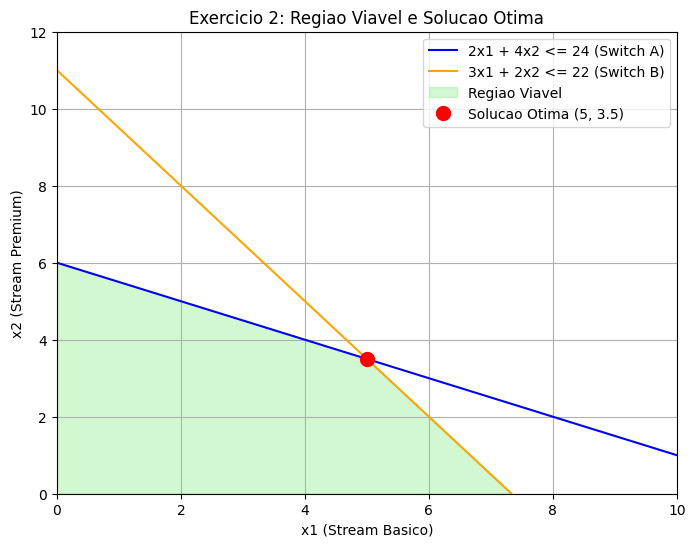

In [3]:
x1 = np.linspace(0, 12, 400)
y1 = (24 - 2*x1) / 4
y2 = (22 - 3*x1) / 2

plt.figure(figsize=(8, 6))
plt.plot(x1, y1, label='2x1 + 4x2 <= 24 (Switch A)', color='blue')
plt.plot(x1, y2, label='3x1 + 2x2 <= 22 (Switch B)', color='orange')

plt.fill([0, 0, 5, 22/3], [0, 6, 3.5, 0], color='lightgreen', alpha=0.4, label='Regiao Viavel')
plt.plot(5, 3.5, 'ro', markersize=10, label='Solucao Otima (5, 3.5)')

plt.xlim(0, 10)
plt.ylim(0, 12)
plt.xlabel('x1 (Stream Basico)')
plt.ylabel('x2 (Stream Premium)')
plt.title('Exercicio 2: Regiao Viavel e Solucao Otima')
plt.legend()
plt.grid(True)
plt.show()

---
### Exercício 3: Treinamento de Modelos de Deep Learning (Machine Learning)

**Contexto:** Um laboratório de pesquisa em IA possui dois tipos de jobs de treinamento para rodar em seu cluster de GPUs: **Modelos NLP ($x_1$)** e **Modelos de Visão Computacional ($x_2$)**. Cada modelo de NLP treinado gera um valor científico de 4 pontos de impacto, enquanto cada modelo de Visão gera 3 pontos.

O treinamento desses modelos é limitado por dois recursos críticos de hardware: o tempo total de uso das GPUs e o armazenamento no sistema de arquivos distribuído (NVMe Pool).
* **Tempo de GPU:** Um modelo NLP exige 3 horas de computação e um de Visão exige 1 hora. O cluster tem 18 horas disponíveis no total para esse experimento.
* **Armazenamento:** Um modelo NLP consome 1 TB de espaço de checkpoint, enquanto um de Visão consome 2 TB. O limite do storage é de 16 TB.

**Formule o problema de PL para maximizar o impacto científico e resolva geometricamente:**

1. Defina a função objetivo e as restrições.
2. Construa o gráfico, hachurando a região de soluções viáveis.
3. Encontre a quantidade ótima de modelos de NLP e Visão a serem treinados.

**--- RESPOSTA ---**

* **Variáveis:** `x1` (NLP), `x2` (Visão Computacional)
* **Objetivo:** Maximizar `Z = 4x1 + 3x2`
* **Restrições:**
  * `3x1 + 1x2 <= 18` (Tempo GPU)
  * `1x1 + 2x2 <= 16` (Armazenamento)
  * `x1, x2 >= 0`
* **Interseção das Restrições:** `3x1 + x2 = 18` e `x1 + 2x2 = 16` -> Ponto (4, 6)
* **Vértices Viáveis:** (0, 0), (0, 8), (6, 0), (4, 6)
* **Solução Ótima:** `x1 = 4`, `x2 = 6`. Impacto Científico Máximo = 34.


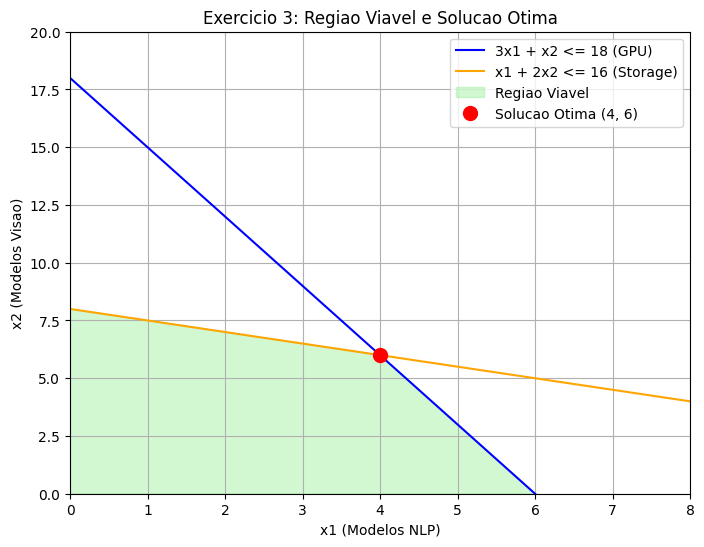

In [4]:
x1 = np.linspace(0, 10, 400)
y1 = 18 - 3*x1
y2 = (16 - x1) / 2

plt.figure(figsize=(8, 6))
plt.plot(x1, y1, label='3x1 + x2 <= 18 (GPU)', color='blue')
plt.plot(x1, y2, label='x1 + 2x2 <= 16 (Storage)', color='orange')

plt.fill([0, 0, 4, 6], [0, 8, 6, 0], color='lightgreen', alpha=0.4, label='Regiao Viavel')
plt.plot(4, 6, 'ro', markersize=10, label='Solucao Otima (4, 6)')

plt.xlim(0, 8)
plt.ylim(0, 20)
plt.xlabel('x1 (Modelos NLP)')
plt.ylabel('x2 (Modelos Visao)')
plt.title('Exercicio 3: Regiao Viavel e Solucao Otima')
plt.legend()
plt.grid(True)
plt.show()

---
### Exercício 4: Design de Hardware (Sistemas Embarcados / IoT)

**Contexto:** Uma empresa de hardware está projetando uma placa de circuito impresso (PCB) para um dispositivo IoT de baixo custo. O circuito integrado principal precisa acomodar dois tipos de blocos lógicos estruturais: **Blocos de Memória Cache ($x_1$)** e **Unidades Aritméticas (ALUs) ($x_2$)**. A eficiência energética do chip aumenta em 5 unidades para cada Bloco de Cache e em 4 unidades para cada ALU adicionada.

O design do chip sofre restrições físicas severas de área total de silício e de dissipação térmica (potência):
* **Área de Silício:** Cada bloco de cache ocupa $2\text{ mm}^2$ e cada ALU ocupa $3\text{ mm}^2$. A área máxima disponível no die é de $18\text{ mm}^2$.
* **Dissipação Térmica:** Devido ao superaquecimento, o consumo de energia não pode passar de $12\text{ mW}$. Cada bloco de cache dissipa $2\text{ mW}$ e cada ALU dissipa $1\text{ mW}$.

**Formule o problema de PL para maximizar a eficiência do chip e resolva geometricamente:**

1. Escreva o modelo matemático correspondente.
2. Plote as retas de restrição e identifique os vértices da região viável.
3. Descubra a configuração ideal ($x_1, x_2$) utilizando as retas de nível da função objetivo.

**--- RESPOSTA ---**

* **Variáveis:** `x1` (Cache), `x2` (ALU)
* **Objetivo:** Maximizar `Z = 5x1 + 4x2`
* **Restrições:**
  * `2x1 + 3x2 <= 18` (Área de Silício)
  * `2x1 + 1x2 <= 12` (Dissipação Térmica)
  * `x1, x2 >= 0`
* **Interseção das Restrições:** `2x1 + 3x2 = 18` e `2x1 + x2 = 12` -> Ponto (4.5, 3)
* **Vértices Viáveis:** (0, 0), (0, 6), (6, 0), (4.5, 3)
* **Solução Ótima:** `x1 = 4.5`, `x2 = 3`. Eficiência Máxima = 34.5.


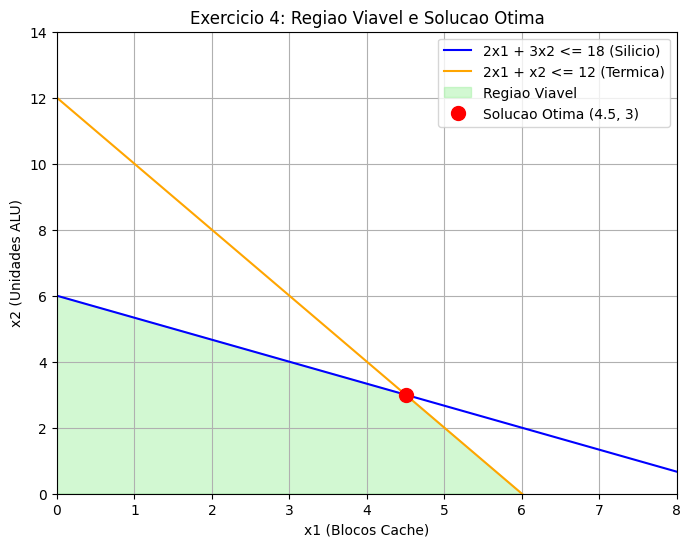

In [5]:
x1 = np.linspace(0, 10, 400)
y1 = (18 - 2*x1) / 3
y2 = 12 - 2*x1

plt.figure(figsize=(8, 6))
plt.plot(x1, y1, label='2x1 + 3x2 <= 18 (Silicio)', color='blue')
plt.plot(x1, y2, label='2x1 + x2 <= 12 (Termica)', color='orange')

plt.fill([0, 0, 4.5, 6], [0, 6, 3, 0], color='lightgreen', alpha=0.4, label='Regiao Viavel')
plt.plot(4.5, 3, 'ro', markersize=10, label='Solucao Otima (4.5, 3)')

plt.xlim(0, 8)
plt.ylim(0, 14)
plt.xlabel('x1 (Blocos Cache)')
plt.ylabel('x2 (Unidades ALU)')
plt.title('Exercicio 4: Regiao Viavel e Solucao Otima')
plt.legend()
plt.grid(True)
plt.show()

---
### Exercício 5: Planejamento de Sprints (Metodologia Ágil / Engenharia de Software)

**Contexto:** Um Tech Lead de uma fábrica de software precisa planejar a próxima Sprint de duas semanas. A equipe é dividida para focar em duas frentes de trabalho: **Desenvolvimento de Novas Funcionalidades ($x_1$)** e **Refatoração de Código / Correção de Bugs ($x_2$)** (unidades medidas em número de tarefas/User Stories). Cada Funcionalidade entrega 8 pontos de valor de negócio ao cliente, e cada Refatoração entrega 5 pontos.

A equipe enfrenta restrições de tempo de desenvolvimento e tempo de garantia de qualidade (QA/Testes):
* **Desenvolvimento:** Cada funcionalidade exige 4 horas de codificação e cada refatoração exige 4 horas. O time tem um teto de 32 horas dedicadas puramente ao desenvolvimento nesta sprint.
* **Testes (QA):** Funcionalidades exigem testes rigorosos, consumindo 2 horas de QA cada. Já as tarefas de refatoração exigem 1 hora de QA. O analista de testes tem apenas 12 horas disponíveis na sprint.

**Formule o problema de PL para maximizar o valor entregue na Sprint e resolva geometricamente:**

1. Determine as variáveis, restrições e a função a ser maximizada.
2. Construa o gráfico cartesiano e determine a região viável.
3. Encontre a solução ótima e discuta se a solução encontrada possui valores inteiros (e a importância disso no contexto prático de engenharia de software).

**--- RESPOSTA ---**

* **Variáveis:** `x1` (Funcionalidades), `x2` (Refatoração)
* **Objetivo:** Maximizar `Z = 8x1 + 5x2`
* **Restrições:**
  * `4x1 + 4x2 <= 32` (Tempo de Dev)
  * `2x1 + 1x2 <= 12` (Tempo de QA)
  * `x1, x2 >= 0`
* **Interseção das Restrições:** `4x1 + 4x2 = 32` e `2x1 + x2 = 12` -> Ponto (4, 4)
* **Vértices Viáveis:** (0, 0), (0, 8), (6, 0), (4, 4)
* **Solução Ótima:** `x1 = 4`, `x2 = 4`. Valor Entregue Máximo = 52.

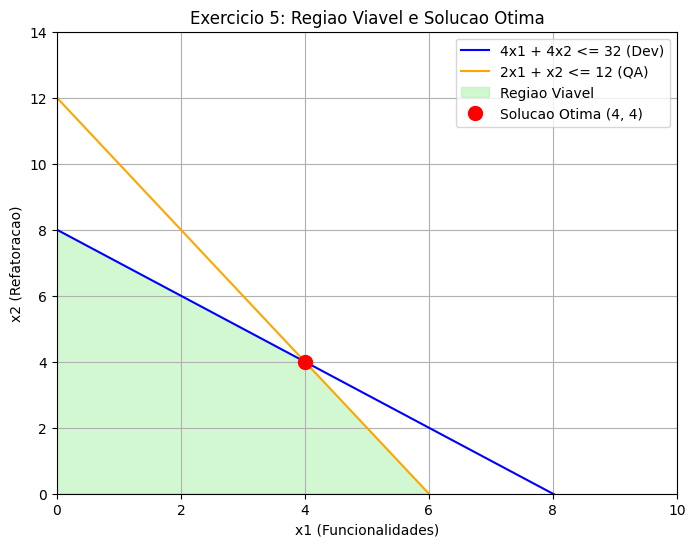

In [6]:
x1 = np.linspace(0, 10, 400)
y1 = 8 - x1
y2 = 12 - 2*x1

plt.figure(figsize=(8, 6))
plt.plot(x1, y1, label='4x1 + 4x2 <= 32 (Dev)', color='blue')
plt.plot(x1, y2, label='2x1 + x2 <= 12 (QA)', color='orange')

plt.fill([0, 0, 4, 6], [0, 8, 4, 0], color='lightgreen', alpha=0.4, label='Regiao Viavel')
plt.plot(4, 4, 'ro', markersize=10, label='Solucao Otima (4, 4)')

plt.xlim(0, 10)
plt.ylim(0, 14)
plt.xlabel('x1 (Funcionalidades)')
plt.ylabel('x2 (Refatoracao)')
plt.title('Exercicio 5: Regiao Viavel e Solucao Otima')
plt.legend()
plt.grid(True)
plt.show()